Epoch 1/200


C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_3412\2062287023.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').last().ffill()
C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 292ms/step - loss: 0.0784 - val_loss: 0.0240
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0106 - val_loss: 0.0175
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0035 - val_loss: 0.0104
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0031 - val_loss: 0.0042
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0022 - val_loss: 7.8470e-04
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0018 - val_loss: 0.0026
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0011 - val_loss: 0.0045
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0013 - val_loss: 0.0

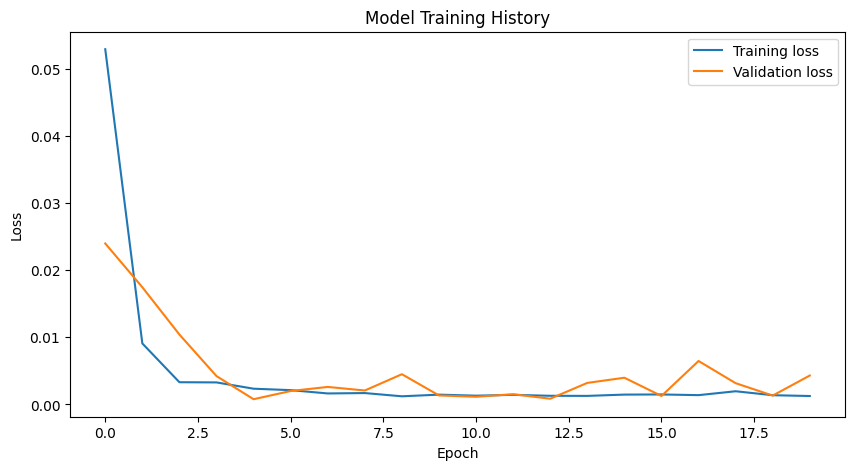

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Training Metrics:
RMSE: 56.7085
MAE: 48.8118
MAPE: 5.41%

Testing Metrics:
RMSE: 69.8850
MAE: 55.8083
MAPE: 2.20%


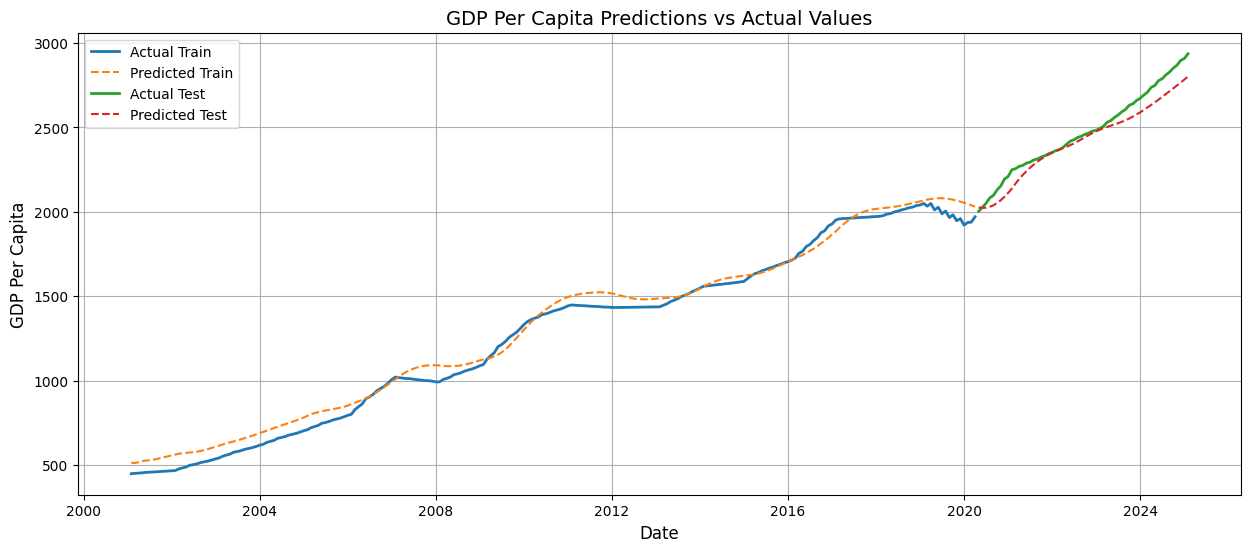

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load and preprocess data
def load_data():
    df = pd.read_csv('Interest Rate and Gdp.csv', parse_dates=['Date'], dayfirst=True)
    df.set_index('Date', inplace=True)
    df = df.resample('M').last().ffill()
    return df[['Average', 'Gdp Per Capita']]

df = load_data()

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
n_features = scaled_data.shape[1]

# Save the scaler for later use in backend
joblib.dump(scaler, 'scaler.save')

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:(i+seq_length), :])  # Use all features
        y.append(data[i+seq_length, 1])      # Predict GDP (second column)
    return np.array(X), np.array(y)

SEQ_LENGTH = 12
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split into train and test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM model
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(SEQ_LENGTH, n_features)))
model.add(Dropout(0.3))
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[es],
                    verbose=1)

# Save the trained model for backend use
model.save('lstm_gdp_predictor.h5')

# Plot training loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Training History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Inverse transform helper function
def inverse_transform_prediction(prediction, scaler, feature_index=1):
    dummy = np.zeros((len(prediction), scaler.n_features_in_))
    dummy[:, feature_index] = prediction.reshape(-1)
    return scaler.inverse_transform(dummy)[:, feature_index]

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform GDP predictions
y_train_actual = inverse_transform_prediction(y_train, scaler)
train_predict = inverse_transform_prediction(train_predict, scaler)
y_test_actual = inverse_transform_prediction(y_test, scaler)
test_predict = inverse_transform_prediction(test_predict, scaler)

# Metrics
def print_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted)/actual)) * 100
    print(f'\n{label} Metrics:')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'MAPE: {mape:.2f}%')
    
print_metrics(y_train_actual, train_predict, 'Training')
print_metrics(y_test_actual, test_predict, 'Testing')

# Plot predictions
plt.figure(figsize=(15,6))
train_end_index = SEQ_LENGTH + len(y_train_actual)
test_start_index = train_end_index
test_end_index = test_start_index + len(y_test_actual)

plt.plot(df.index[SEQ_LENGTH:train_end_index], y_train_actual, label='Actual Train', linewidth=2)
plt.plot(df.index[SEQ_LENGTH:train_end_index], train_predict, '--', label='Predicted Train', linewidth=1.5)
plt.plot(df.index[test_start_index:test_end_index], y_test_actual, label='Actual Test', linewidth=2)
plt.plot(df.index[test_start_index:test_end_index], test_predict, '--', label='Predicted Test', linewidth=1.5)

plt.title('GDP Per Capita Predictions vs Actual Values', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('GDP Per Capita', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
